In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score

import statsmodels.api as sm

df = pd.read_csv("dragon_data.csv")

print(df.head())

print(df.info())

# Summary statistics
print(df.describe())

      SPC   AGE     MASS   WSP   HID     SPD   FHO
0  Wyvern    16     1304   4.0  4.83    4800   611
1  Dragon  2726  3693174  52.0  4.82  114400  1960
2  Dragon   377   154201  19.4  4.61   42680  1123
3   Hydra   169    40146  13.0  2.65    7800   706
4  Dragon  1571  1549315  39.6  1.49   87120  1441
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPC     500 non-null    object 
 1   AGE     500 non-null    int64  
 2   MASS    500 non-null    int64  
 3   WSP     500 non-null    float64
 4   HID     500 non-null    float64
 5   SPD     500 non-null    int64  
 6   FHO     500 non-null    int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 27.5+ KB
None
              AGE          MASS         WSP         HID            SPD  \
count   500.00000  5.000000e+02  500.000000  500.000000     500.000000   
mean    461.47400  3.092487e+05   18.1994

In [3]:
print(df.isnull().sum())

SPC     0
AGE     0
MASS    0
WSP     0
HID     0
SPD     0
FHO     0
dtype: int64


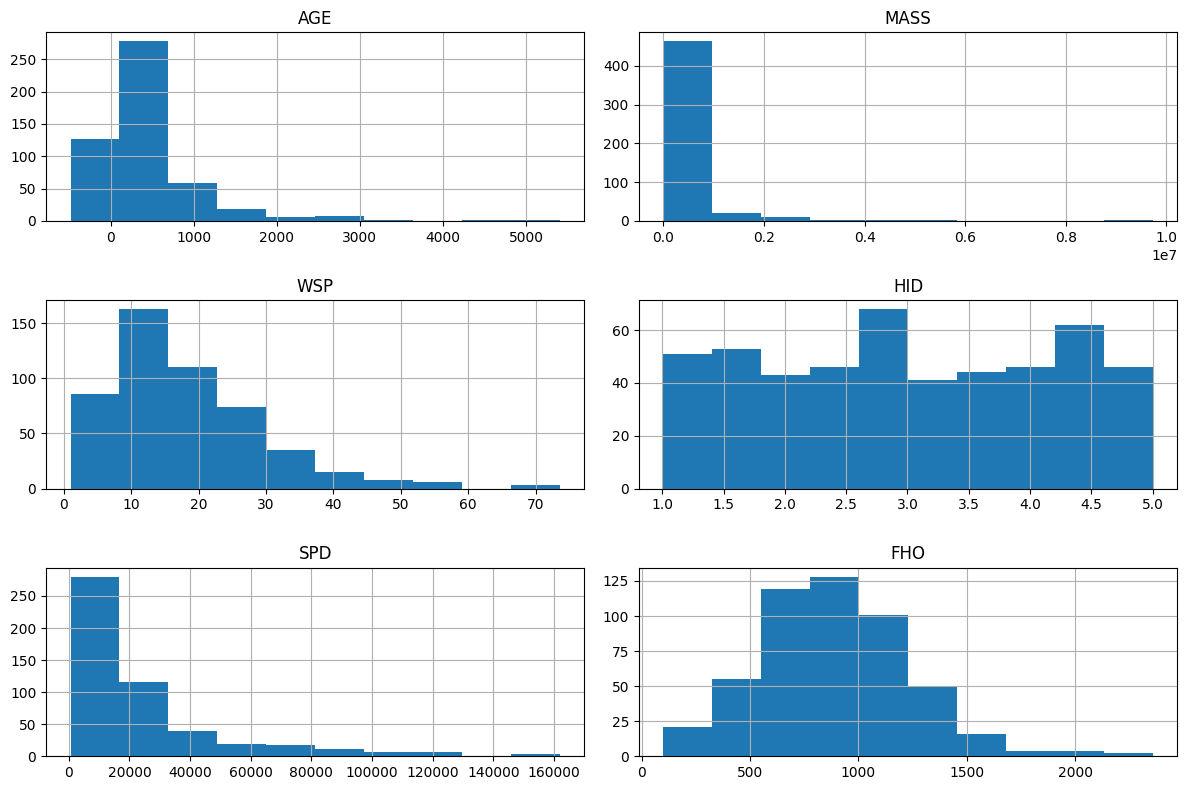

In [ ]:
numeric_cols = ['AGE', 'MASS', 'WSP', 'HID', 'SPD', 'FHO']

df[numeric_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [24]:
df['SPC'] = df['SPC'].replace('Wyvernn', 'Wyvern')

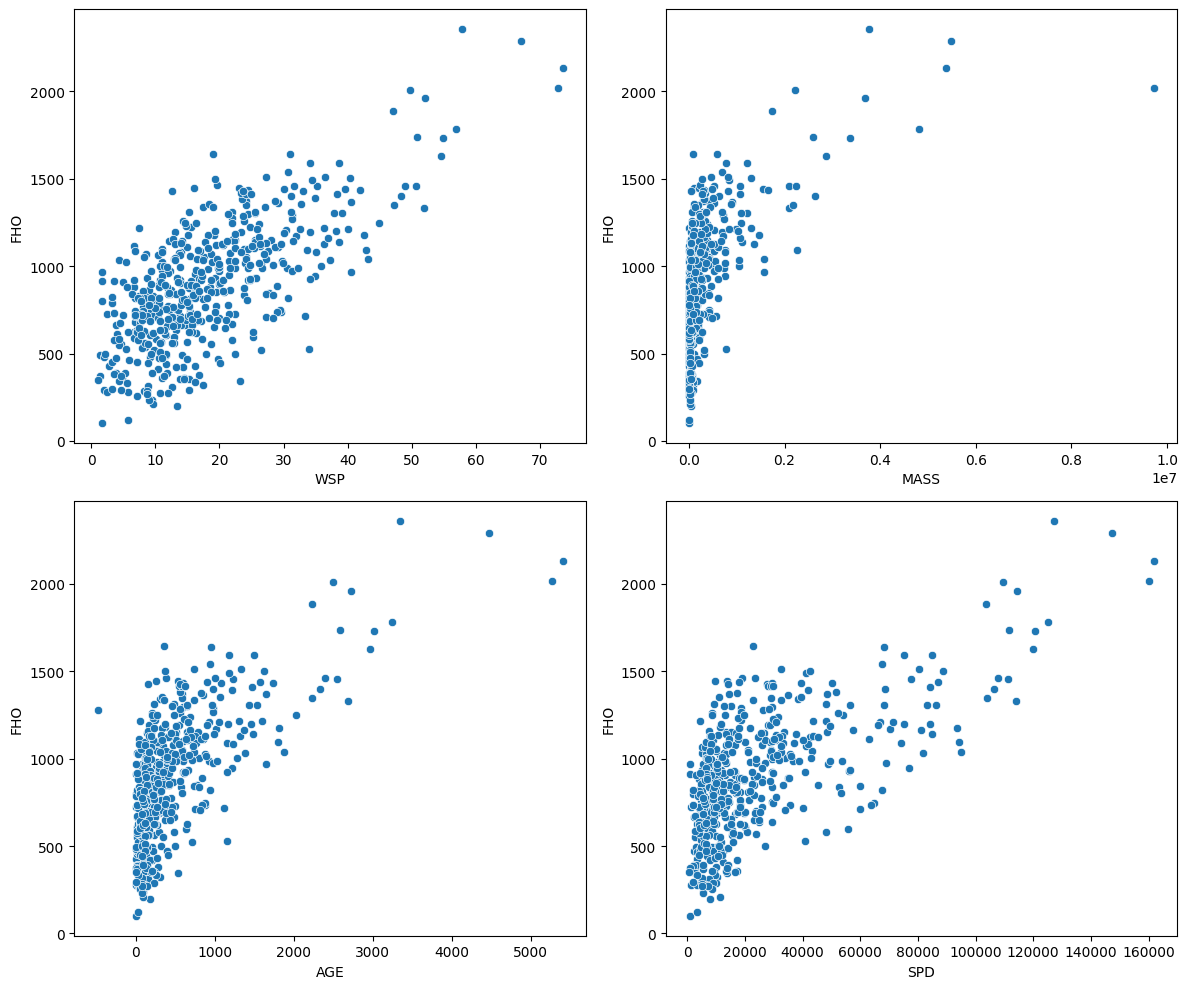

In [25]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

sns.scatterplot(data=df, x='WSP', y='FHO', ax=axes[0,0])
sns.scatterplot(data=df, x='MASS', y='FHO', ax=axes[0,1])
sns.scatterplot(data=df, x='AGE', y='FHO', ax=axes[1,0])
sns.scatterplot(data=df, x='SPD', y='FHO', ax=axes[1,1])

plt.tight_layout()
plt.show()

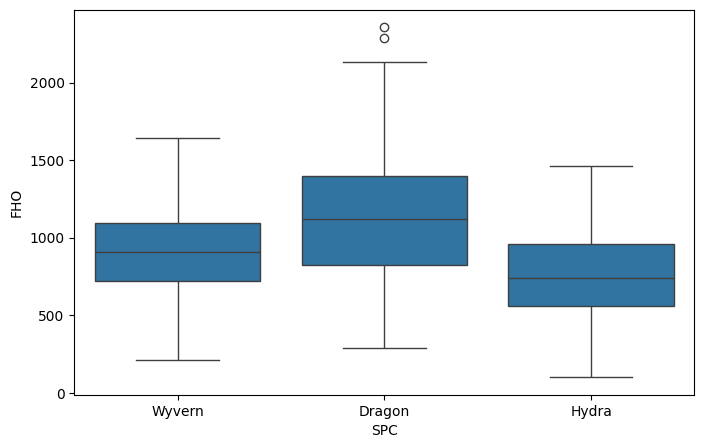

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='SPC', y='FHO')
plt.show()

In [27]:
# Converting categorical variable into a dummy

df_encoded = pd.get_dummies(df, columns=['SPC'], drop_first=True)

X = df_encoded.drop('FHO', axis=1)
y = df_encoded['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**Model 1 :Wingspan (WSP)**

In [28]:
X = df[['WSP']]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_wsp = LinearRegression()
model_wsp.fit(X_train, y_train)

train_pred = model_wsp.predict(X_train)
test_pred = model_wsp.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print('Train R2:', train_r2)
print('Test R2:', test_r2)

Train R2: 0.494672105612152
Test R2: 0.5416536400319366


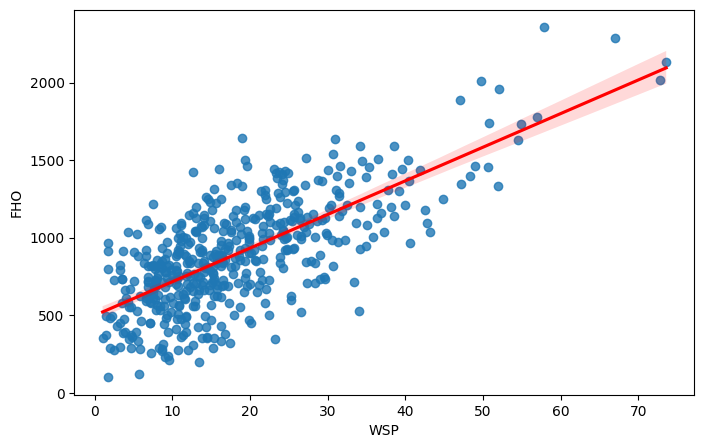

In [29]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='WSP', y='FHO', line_kws={'color':'red'})
plt.show()

The regression model using Wingspan achieved a training R² of 0.495 and a test R² of 0.542. The scatter plot with the fitted regression line showed a clear positive relationship between wingspan and flame heat output. Larger dragons generally produced hotter flames.

The similar training and test R² values suggest that the model generalises well and is not overfitting.

**Model 2: Mass (MASS)**

In [30]:
X = df[['MASS']]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_mass = LinearRegression()
model_mass.fit(X_train, y_train)

train_pred = model_mass.predict(X_train)
test_pred = model_mass.predict(X_test)

print('Train R2:', r2_score(y_train, train_pred))
print('Test R2:', r2_score(y_test, test_pred))

Train R2: 0.3316798226981259
Test R2: 0.36006158360421603


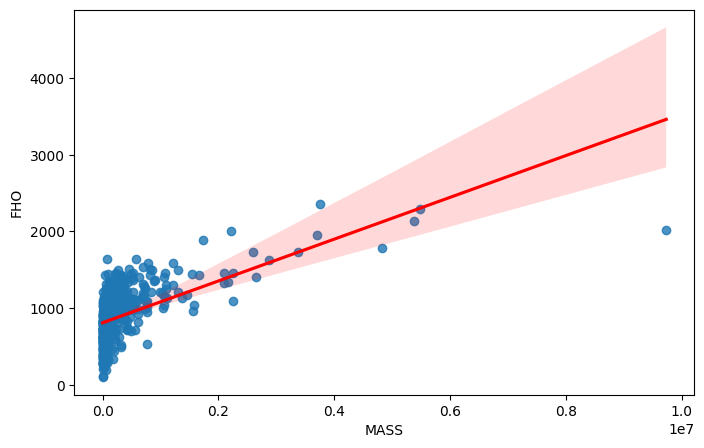

In [31]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='MASS', y='FHO', line_kws={'color':'red'})
plt.show()

The Mass model achieved a training R² of 0.332 and a test R² of 0.360. The scatter plot showed a positive relationship between mass and flame heat output, although the relationship was weaker than that observed for wingspan.

The lower R² values indicate that mass explains less of the variation in flame heat output than wingspan.

**Model 3: Age (AGE)**

In [32]:
X = df[['AGE']]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_age = LinearRegression()
model_age.fit(X_train, y_train)

train_pred = model_age.predict(X_train)
test_pred = model_age.predict(X_test)

print('Train R2:', r2_score(y_train, train_pred))
print('Test R2:', r2_score(y_test, test_pred))

Train R2: 0.4335896587740389
Test R2: 0.4786814734073791


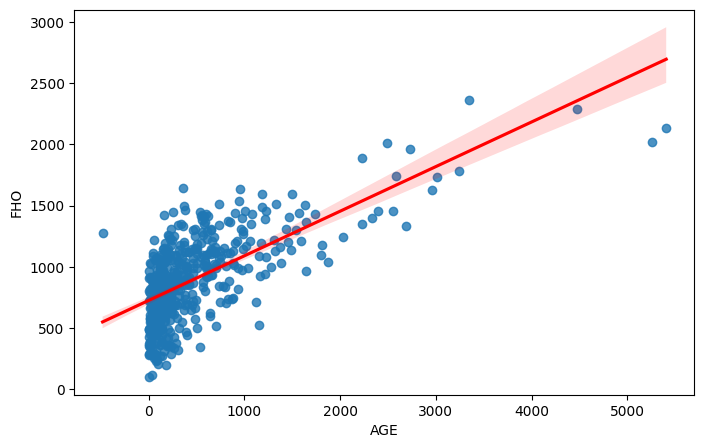

In [33]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='AGE', y='FHO', line_kws={'color':'red'})
plt.show()

The Age model achieved a training R² of 0.434 and a test R² of 0.479. The scatter plot showed a moderate positive relationship between age and flame heat output.

This suggests that older dragons tend to produce hotter flames, although age is not as strong a predictor as wingspan.

**Model 4: Species (SPC)**

In [34]:
X = pd.get_dummies(df[['SPC']], drop_first=True)
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_spc = LinearRegression()
model_spc.fit(X_train, y_train)

train_pred = model_spc.predict(X_train)
test_pred = model_spc.predict(X_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))

Train R²: 0.17220337586670464
Test R²: 0.0890689249986053


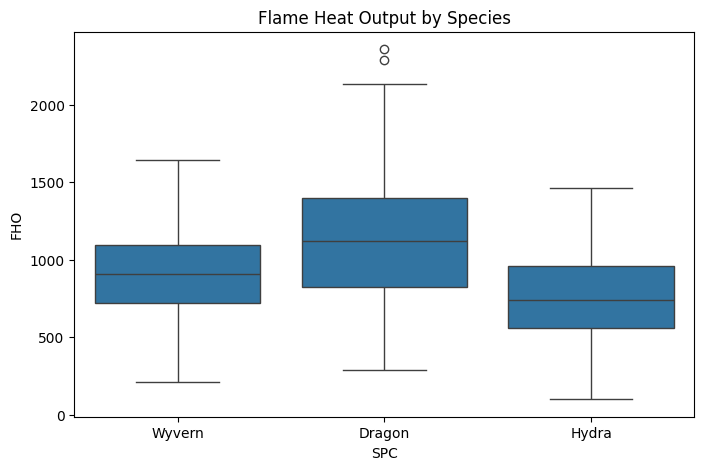

In [37]:

plt.figure(figsize=(8,5))
sns.boxplot(x='SPC', y='FHO', data=df)
plt.title('Flame Heat Output by Species')
plt.show()

The boxplot shows clear differences in Flame Heat Output between species. Dragons generally have the highest flame temperatures, with a higher median FHO and several extreme values above 2200°C. Wyverns exhibit intermediate flame temperatures, while Hydras tend to have the lowest median FHO. However, there is substantial overlap between the distributions, which helps explain why Species alone has relatively low predictive power (test R² = 0.089).



**CONCLUSION**

Overall, Wingspan was the most informative predictor, achieving the highest test R² value. Age was the second strongest predictor, followed by Mass. Species was the weakest predictor and explained only a small proportion of the variation in flame heat output. These results suggest that physical characteristics, particularly wingspan, are more important than species classification when predicting flame heat output.

**2. Multiple Variable Regression:**

In [44]:
features = ['WSP', 'MASS']

X = df[features]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model1 = LinearRegression()
model1.fit(X_train, y_train)

train_pred = model1.predict(X_train)
test_pred = model1.predict(X_test)

print('Train R2:', r2_score(y_train, train_pred))
print('Test R2:', r2_score(y_test, test_pred))

Train R2: 0.49553638193211946
Test R2: 0.5423836106808952


In [45]:
features = ['WSP', 'MASS', 'AGE']

X = df[features]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train, y_train)

train_pred = model2.predict(X_train)
test_pred = model2.predict(X_test)

print('Train R2:', r2_score(y_train, train_pred))
print('Test R2:', r2_score(y_test, test_pred))

Train R2: 0.49705180327634235
Test R2: 0.5431216327395993


In [46]:
X = df_encoded.drop('FHO', axis=1)
y = df_encoded['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

full_model = LinearRegression()
full_model.fit(X_train, y_train)

train_pred = full_model.predict(X_train)
test_pred = full_model.predict(X_test)

print('Train R2:', r2_score(y_train, train_pred))
print('Test R2:', r2_score(y_test, test_pred))

Train R2: 0.5029040351386589
Test R2: 0.5400517122651561


Adding Mass to Wingspan produced almost no improvement in performance. Similarly, adding Age resulted in only a very small increase in test R² from 0.542 to 0.543.

The Full Model achieved the highest training R² (0.503), indicating a slightly better fit to the training data. However, its test R² decreased slightly to 0.540, suggesting that the additional variables contributed little useful predictive information and may have introduced some noise.

**Best Performing Model**

The WSP + MASS + AGE model achieved the highest test R² value (0.543) and therefore provided the best predictive performance on unseen data.

Although the Full Model used more variables, the increase in model complexity did not improve generalisation. This suggests that Wingspan, Mass and Age capture most of the information needed to predict Flame Heat Output.

The results indicate that Wingspan is the dominant predictor of Flame Heat Output. Adding additional variables provides only marginal improvements. The small difference between training and test performance across all models suggests that overfitting is limited. Overall, the WSP + MASS + AGE model provides the best balance between accuracy, simplicity and interpretability.

**Model Comparison**

The results show that adding variables does not necessarily improve predictive performance. Wingspan alone achieved a test R² of 0.542, while adding Mass increased test R² only marginally to 0.542. Including Age produced the highest test R² of 0.543.

The Full Model achieved the highest training R² (0.503), indicating a slightly better fit to the training data. However, its test R² decreased to 0.540, suggesting that the additional variables provided little useful predictive information.

There is little evidence of overfitting because the training and test R² values remain very similar across all models. The best-performing model was the WSP + MASS + AGE model because it achieved the highest test R² while remaining relatively simple and interpretable.

**4. Interpretability:**

In [47]:
features = ['WSP', 'MASS', 'AGE']

X = df[features]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

best_model = LinearRegression()
best_model.fit(X_train,y_train)

coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_
})

print(coef_table)
print("Intercept:", best_model.intercept_)

  Feature  Coefficient
0     WSP    23.223540
1    MASS     0.000071
2     AGE    -0.114641
Intercept: 493.2498761419461


**Model Evaluation**

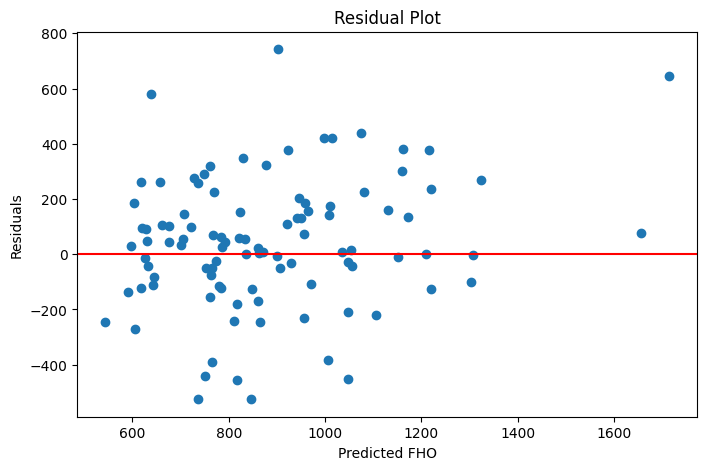

In [51]:
residuals = y_test - test_pred

plt.figure(figsize=(8,5))
plt.scatter(test_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted FHO")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [49]:
mae = mean_absolute_error(y_test, test_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 181.43385777506685
RMSE: 240.564279652933


In [50]:
scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print("Mean CV R²:", scores.mean())

[0.45289643 0.52946821 0.41987826 0.54640753 0.40354355]
Mean CV R²: 0.47043879470611377


**Question 6**

In [52]:
df['WSP_AGE'] = df['WSP'] * df['AGE']
df['WSP_MASS'] = df['WSP'] * df['MASS']
df['LOG_MASS'] = np.log(df['MASS'])

features = [
    'WSP',
    'MASS',
    'AGE',
    'WSP_AGE',
    'WSP_MASS',
    'LOG_MASS'
]

X = df[features]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

feature_model = LinearRegression()
feature_model.fit(X_train,y_train)

train_pred = feature_model.predict(X_train)
test_pred = feature_model.predict(X_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))

Train R²: 0.5032499800813546
Test R²: 0.5485787798858666
